> ⚠️ **데이터 범위(정직)**: 매출은 **상권(자치구·업종·분기) 합계**이고 'per-store'는 **평균**(합계÷점포수)이다. **개별 점포 매출·점포 간 분산 데이터는 없다.** 따라서 (1) 추정 매출은 *상권 평균*이지 신규 점포가 그만큼 번다는 뜻이 아니며, (2) BEP·p_roi(손익분기 초과확률)는 **점포 분산이 아니라 모델 예측오차 기반이라 참고용**이다. **개별 점포 수익·리스크 예측이 아님.**

> ⚠️ **DE-LEAKED 정직본** — 누설 5개 제거 재실행. 3분류 정확도 **0.66**(누설본 0.84).
> ✅ `expected_monthly_sales`는 **점포당 추정 월매출**로 수정됨(회귀 타깃 log_sales_per_store). BEP(점포단위)와 직접 비교 가능해 p_roi도 정합.

# 07. 창업 입지 평가 (v2)

## 한 줄
자치구 + 업종 (+ 선택: 투자금) 입력 → **매출 분위 + 확률 + 추정 월매출 + BEP + 마진/임대료/공실률 컨텍스트** 반환.

## 강의 절차 그대로
L03 KNN → L04 분할/표준화 → L05 회귀 비교 → L07 로지스틱 → L08 트리/CV/GridSearch → L10 RF + permutation_importance

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 강의 매핑 주석
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV  # L04, L08-2
from sklearn.preprocessing import StandardScaler                                                       # L04
from sklearn.linear_model import LogisticRegression, LinearRegression                                  # L07, L05
from sklearn.neighbors import KNeighborsClassifier                                                     # L03
from sklearn.tree import DecisionTreeClassifier, plot_tree                                             # L08-1
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor                             # L10
from sklearn.inspection import permutation_importance                                                  # L10
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report          # L07

PROCESSED_DIR = Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project/data/processed')
df = pd.read_csv(PROCESSED_DIR / 'features.csv')

# 식별자·타깃 분리
id_cols = ['gu','biz','q','q_int']
target_cls = 'sales_class'
target_reg = 'log_sales_per_store'  # 점포당(자치구 합계 아님)
feature_cols = [c for c in df.columns if c not in id_cols + ['THSMON_SELNG_AMT', 'log_sales', target_reg, target_cls, 'sales_per_store', 'log_sales_per_store', 'store_class']]
feature_cols = [c for c in feature_cols if c not in ['avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales']]  # de-leak(feature_cols)
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].mean(numeric_only=True))
print('features:', df.shape, '| 변수:', len(feature_cols))

features: (17568, 164) | 변수: 149


## §1. 데이터 준비 + 분할 (L03~L04)

In [2]:
# 입력 행렬·타깃 분리
X = df[feature_cols].values
y = df[target_cls].values

# stratify로 클래스 비율 유지 (low/mid/high가 한쪽에 몰리지 않게)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('학습:', X_train.shape, '테스트:', X_test.shape)
print('클래스 분포:', pd.Series(y_train).value_counts().to_dict())

학습: (14054, 149) 테스트: (3514, 149)
클래스 분포: {'high': 4778, 'mid': 4638, 'low': 4638}


## §2. 표준화 (L04)

In [3]:
# 거리 기반 KNN/Logistic은 스케일에 민감 — 학습 셋으로만 fit
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
print('평균≈', round(X_train_s.mean(), 4), '표준편차≈', round(X_train_s.std(), 4))

평균≈ 0.0 표준편차≈ 0.9966


## §3. KNN 분류 + k 튜닝 (L03)

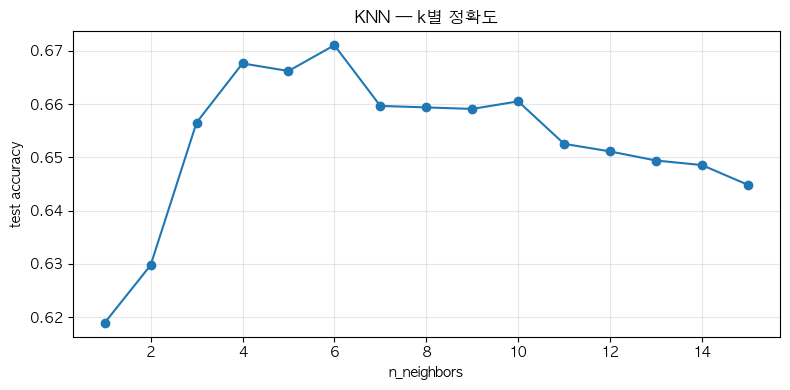

최적 k: 6
   k  test_acc
5  6  0.671030
3  4  0.667615
4  5  0.666192


In [4]:
# 과대/과소적합 진단 — k를 1~15까지 변화시키며 테스트 정확도 관찰
accs = []
for k in range(1, 16):
    knn_ = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    accs.append((k, knn_.score(X_test_s, y_test)))
acc_df = pd.DataFrame(accs, columns=['k','test_acc'])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(acc_df['k'], acc_df['test_acc'], marker='o')
ax.set_xlabel('n_neighbors'); ax.set_ylabel('test accuracy')
ax.set_title('KNN — k별 정확도'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
best_k = int(acc_df.sort_values('test_acc', ascending=False).iloc[0]['k'])
print('최적 k:', best_k); print(acc_df.sort_values('test_acc', ascending=False).head(3))

## §4. 로지스틱 회귀 (L07)

In [5]:
# L07: 이름은 회귀지만 분류 모델. 클래스 확률(predict_proba) 제공
lr = LogisticRegression(max_iter=2000, n_jobs=-1).fit(X_train_s, y_train)
print('Logistic acc:', round(lr.score(X_test_s, y_test), 3))

# 혼동행렬 — 어느 클래스가 어느 클래스로 잘못 분류되는지
yp_lr = lr.predict(X_test_s)
print('\n[혼동행렬]')
print(pd.DataFrame(confusion_matrix(y_test, yp_lr, labels=['low','mid','high']),
                   index=['low','mid','high'], columns=['pred_low','pred_mid','pred_high']))

Logistic acc: 0.631

[혼동행렬]
      pred_low  pred_mid  pred_high
low        757       296        107
mid        310       609        240
high       123       219        853


## §5. 결정 트리 + 단순 트리 시각화 (L08-1)

Tree acc: 0.595


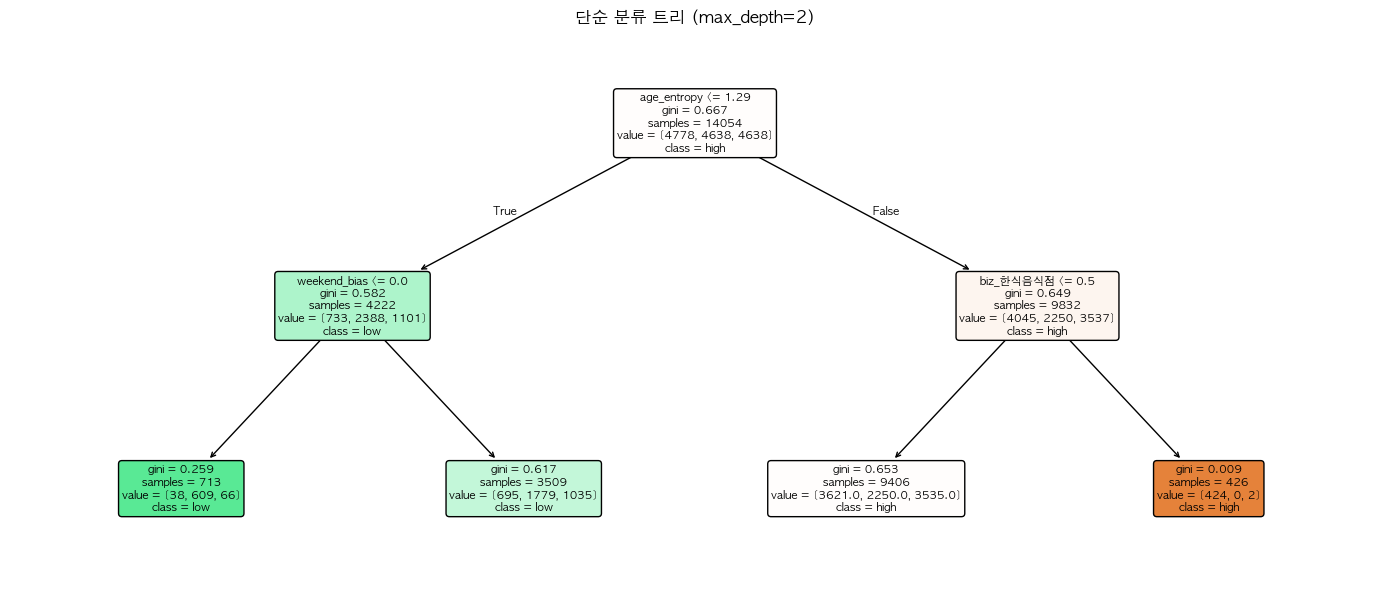

In [6]:
# 본 모델: 깊이 8
dt = DecisionTreeClassifier(max_depth=8, min_samples_split=5, random_state=42).fit(X_train, y_train)
print('Tree acc:', round(dt.score(X_test, y_test), 3))

# 시각화용: 깊이 2 — 한 페이지에 보이게
dt_small = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(dt_small, feature_names=feature_cols, class_names=dt_small.classes_,
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.title('단순 분류 트리 (max_depth=2)'); plt.tight_layout(); plt.show()

## §6. StratifiedKFold + GridSearchCV (L08-2)

In [7]:
# 5겹 교차검증으로 트리 하이퍼파라미터 탐색
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'max_depth': [6, 10, None], 'min_samples_split': [2, 5, 10]}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42),
                  param_grid, cv=skf, scoring='f1_macro', n_jobs=-1)
gs.fit(X_train, y_train)
print('Best params:', gs.best_params_, '| CV f1_macro:', round(gs.best_score_, 3))
print('테스트 acc:', round(gs.best_estimator_.score(X_test, y_test), 3))

Best params: {'max_depth': 10, 'min_samples_split': 10} | CV f1_macro: 0.608
테스트 acc: 0.611


## §7. RandomForest + permutation_importance (L10)

RF acc: 0.662
              precision    recall  f1-score   support

        high       0.74      0.72      0.73      1195
         low       0.67      0.71      0.69      1160
         mid       0.58      0.56      0.57      1159

    accuracy                           0.66      3514
   macro avg       0.66      0.66      0.66      3514
weighted avg       0.66      0.66      0.66      3514



Exception ignored in: <function ResourceTracker.__del__ at 0x11206b2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/Users/ijunsu/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Exception ignored in: <function ResourceTracker.__del__ at 0x110fd72e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x10426b2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x120bd72e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


...

Exception ignored in: <function ResourceTracker.__del__ at 0x107bcb2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1050d72e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1095eb2e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1088472e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x1060632e0>
Traceback (most recent call last):
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/ijunsu/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


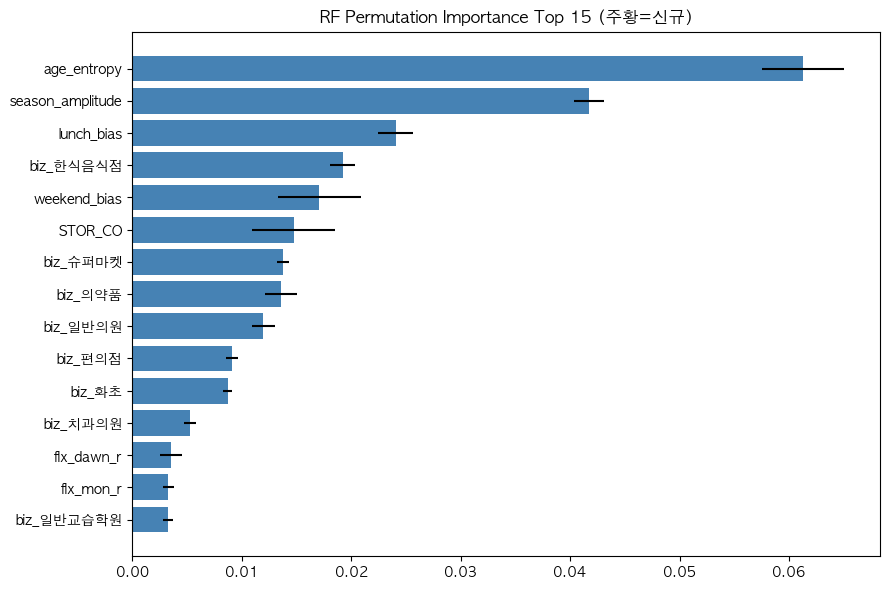

In [8]:
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1).fit(X_train, y_train)
print('RF acc:', round(rf.score(X_test, y_test), 3))
print(classification_report(y_test, rf.predict(X_test)))

# permutation_importance: 변수 셔플 → 성능 하락폭이 진짜 기여도
perm = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({'feature': feature_cols,
                         'perm_imp': perm.importances_mean,
                         'std': perm.importances_std}).sort_values('perm_imp', ascending=False).head(15)

# 신규 외부 변수 강조
new_vars = {'rent_index_q','rent_growth_yoy','vacancy_rate','margin_proxy','gu_pop_density',
            'closure_count','single_household','transaction_count_q','avg_transaction_price',
            'gu_foreign_ratio','rent_to_sales','vacancy_change_q','pop_density_log',
            'single_ratio','closure_per_store','margin_zscore'}
colors = ['orange' if f in new_vars else 'steelblue' for f in perm_df['feature']]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['feature'][::-1], perm_df['perm_imp'][::-1],
        xerr=perm_df['std'][::-1], color=colors[::-1])
ax.set_title('RF Permutation Importance Top 15 (주황=신규)')
plt.tight_layout(); plt.show()

## §8. 매출 회귀 모델 — 추정 월매출용 (L05 + L10)

In [9]:
# 분류와 별개로 회귀 RF를 학습 → evaluate_location()에서 예상 매출 산출에 사용
# σ(예측 표준편차)는 p_roi 계산에서 정규분포 가정에 쓰임
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
rf_reg.fit(df[feature_cols].values, df[target_reg].values)
sigma_log = float(np.std(df[target_reg].values - rf_reg.predict(df[feature_cols].values)))
print('회귀 RF 학습 완료. σ(log_sales)=', round(sigma_log, 3))

회귀 RF 학습 완료. σ(log_sales)= 1.143


## §9. `evaluate_location()` — 본 노트북 핵심 함수

In [10]:
# 업종별 도메인 상수 — 보고서 §3.2에 출처 명시
# (margin_rate, standard_invest, labor_monthly) 가 BEP 계산의 입력
INDUSTRY_PARAMS = {
    '한식음식점':         {'group':'food',   'margin_rate':0.20, 'standard_invest':100_000_000, 'labor_monthly':6_000_000},
    '커피-음료':          {'group':'food',   'margin_rate':0.20, 'standard_invest':100_000_000, 'labor_monthly':6_000_000},
    '일식음식점':         {'group':'food',   'margin_rate':0.20, 'standard_invest':120_000_000, 'labor_monthly':7_000_000},
    '편의점':            {'group':'retail', 'margin_rate':0.25, 'standard_invest': 80_000_000, 'labor_monthly':4_000_000},
    '슈퍼마켓':          {'group':'retail', 'margin_rate':0.25, 'standard_invest': 80_000_000, 'labor_monthly':4_000_000},
    '반찬가게':          {'group':'retail', 'margin_rate':0.25, 'standard_invest': 50_000_000, 'labor_monthly':4_000_000},
    '의약품':            {'group':'service','margin_rate':0.40, 'standard_invest':150_000_000, 'labor_monthly':8_000_000},
    '일반의원':           {'group':'service','margin_rate':0.40, 'standard_invest':200_000_000, 'labor_monthly':10_000_000},
    '일반의류':           {'group':'retail', 'margin_rate':0.30, 'standard_invest': 80_000_000, 'labor_monthly':4_000_000},
    '수산물판매':         {'group':'retail', 'margin_rate':0.20, 'standard_invest': 60_000_000, 'labor_monthly':4_000_000},
    '컴퓨터및주변장치판매': {'group':'retail', 'margin_rate':0.20, 'standard_invest': 80_000_000, 'labor_monthly':4_000_000},
}

def evaluate_location(gu: str, biz: str, q_int: int | None = None, investment: int | None = None):
    """창업 입지 평가 함수.

    Parameters
    ----------
    gu : 자치구명 (예: '강남구')
    biz : 업종명 (예: '커피-음료')
    q_int : 평가 시점 분기 (생략 시 가장 최신)
    investment : 투자금 (원). 생략 시 업종 표준 투자금 사용.

    Returns
    -------
    dict :
        predicted_class : 매출 분위 (low/mid/high)
        class_probabilities : 각 클래스 확률
        expected_monthly_sales : 추정 월매출 (원, **점포당**)
        breakeven_monthly_sales : 손익분기 월매출 (BEP)
        p_roi : 매출이 BEP를 넘을 확률
        context : 임대료/공실률/마진 등 입지 컨텍스트
    """
    # 1. (gu, biz)에 해당하는 행 조회
    sub = df[(df['gu'] == gu) & (df['biz'] == biz)]
    if sub.empty:
        return {'error': f'데이터 없음: gu={gu}, biz={biz}'}

    # 2. 평가 시점 행 선택 (가장 최신 또는 지정 분기)
    if q_int is None:
        row = sub.sort_values('q_int').iloc[-1]
    else:
        row_match = sub[sub['q_int'] == q_int]
        row = row_match.iloc[0] if not row_match.empty else sub.sort_values('q_int').iloc[-1]

    # 3. 입력 벡터 구성 → 분류기 + 회귀기 호출
    x = row[feature_cols].values.reshape(1, -1)
    proba = rf.predict_proba(x)[0]
    pred_class = rf.predict(x)[0]
    cls_proba = dict(zip(rf.classes_, np.round(proba, 3)))

    # 4. 추정 월매출 — 회귀 모델 예측값(log_sales) → exp 환원
    log_sales_pred = float(rf_reg.predict(x)[0])
    expected_monthly_sales = float(np.exp(log_sales_pred))

    # 5. BEP 계산 (설계서 §3.2 공식 그대로)
    params = INDUSTRY_PARAMS.get(biz, {'group':'other','margin_rate':0.20,
                                         'standard_invest':100_000_000,'labor_monthly':5_000_000})
    invest = investment if investment is not None else params['standard_invest']
    invest_depreciation = invest / 36                           # 36개월 분할 상각
    # 임대료 proxy: 임대료지수 × 단위면적당 임대료 (50,000원/㎡ 가정)
    rent_proxy = float(row.get('rent_index_q', 100)) * 50_000
    fixed_monthly = rent_proxy + params['labor_monthly'] + invest_depreciation
    bep = fixed_monthly / params['margin_rate']

    # 6. p_roi = P(매출 ≥ BEP). σ는 회귀 RMSE로, 정규분포 가정
    # tanh로 부드럽게 매핑 — 0~1 범위 보장
    p_roi = float(1 - 0.5*(1 + np.tanh((np.log(max(bep, 1)) - log_sales_pred) / max(sigma_log, 1e-3))))

    # 7. 결과 dict 반환
    return {
        'gu': gu, 'biz': biz, 'q_int': int(row['q_int']),
        'predicted_class': pred_class,
        'class_probabilities': cls_proba,
        'expected_monthly_sales': round(expected_monthly_sales, 0),
        'breakeven_monthly_sales': round(bep, 0),
        'p_roi': round(p_roi, 3),
        'context': {
            'rent_index_q':    float(row.get('rent_index_q', np.nan)),    # 신규 외부 (team1)
            'vacancy_rate':    float(row.get('vacancy_rate', np.nan)),    # 신규 외부 (team1)
            'margin_proxy':    float(row.get('margin_proxy', np.nan)),    # 신규 외부 (team1)
            'gu_pop_density':  float(row.get('gu_pop_density', np.nan)),  # 신규 외부 (team4)
            'closure_count':   float(row.get('closure_count', np.nan)),   # 신규 외부 (team4)
            'industry_group':  params['group'],
            'investment_input_KRW': int(invest),
        }
    }

# 시연 — 3가지 입력 케이스
print(json.dumps(evaluate_location('강남구', '커피-음료'),
                 ensure_ascii=False, indent=2, default=str))
print(json.dumps(evaluate_location('성동구', '일식음식점', investment=200_000_000),
                 ensure_ascii=False, indent=2, default=str))
print(json.dumps(evaluate_location('중랑구', '편의점'),
                 ensure_ascii=False, indent=2, default=str))

{
  "gu": "강남구",
  "biz": "커피-음료",
  "q_int": 20254,
  "predicted_class": "high",
  "class_probabilities": {
    "high": 0.904,
    "low": 0.007,
    "mid": 0.089
  },
  "expected_monthly_sales": 157963333.0,
  "breakeven_monthly_sales": 69579559.0,
  "p_roi": 0.808,
  "context": {
    "rent_index_q": 102.76267857142857,
    "vacancy_rate": 8.483333333333333,
    "margin_proxy": 1659.6961306477651,
    "gu_pop_density": 13651.4177,
    "closure_count": 2870.5331338178707,
    "industry_group": "food",
    "investment_input_KRW": 100000000
  }
}
{
  "gu": "성동구",
  "biz": "일식음식점",
  "q_int": 20254,
  "predicted_class": "mid",
  "class_probabilities": {
    "high": 0.283,
    "low": 0.19,
    "mid": 0.527
  },
  "expected_monthly_sales": 53430664.0,
  "breakeven_monthly_sales": 90103403.0,
  "p_roi": 0.286,
  "context": {
    "rent_index_q": 109.3025,
    "vacancy_rate": 2.675,
    "margin_proxy": 3266.02429038677,
    "gu_pop_density": 17411.3879,
    "closure_count": 2870.5331338178707,

## §10. 자치구 × 업종 P(high) 매트릭스

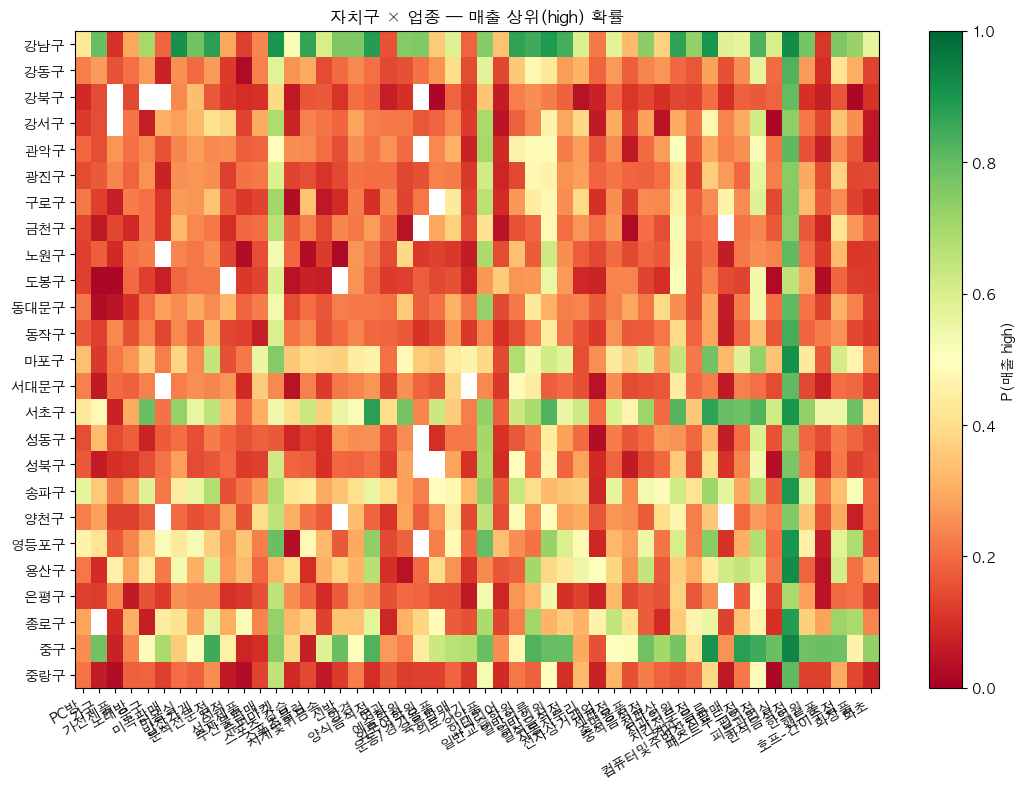

In [11]:
# 모든 (gu, biz) 조합에 대해 evaluate 호출 → 매출 상위 확률을 히트맵으로
results = []
for gu in df['gu'].unique():
    for b in df['biz'].unique():
        r = evaluate_location(gu, b)
        if 'error' in r: continue
        results.append({'gu': gu, 'biz': b,
                        'class': r['predicted_class'],
                        'p_high': r['class_probabilities'].get('high', 0)})
rdf = pd.DataFrame(results)
pivot = rdf.pivot(index='gu', columns='biz', values='p_high')

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(pivot.shape[1])); ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(pivot.shape[0])); ax.set_yticklabels(pivot.index)
plt.colorbar(im, label='P(매출 high)')
ax.set_title('자치구 × 업종 — 매출 상위(high) 확률')
plt.tight_layout(); plt.show()

## §11. 한계

본 모델은 **자치구 + 업종 + 투자금** 까지만 받는 MVP다.
설계서 §1.1의 완전한 입력(**좌표/주소/층수**)은 후속 작업:
- `09_point_location.ipynb`(가칭) — Kakao 지오코딩 + point-in-polygon
- 층수 계수 적용 (트랙1: 도메인 사전값, 트랙2: 소상공인 데이터 실증)